In [1]:
from transformers import AutoModelForImageClassification, AutoImageProcessor
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

import evaluate
import numpy as np
import accelerate

from sklearn.metrics import confusion_matrix

In [2]:
device = accelerate.Accelerator().device
device

device(type='mps')

In [3]:
##### Step 1: Load your custom dataset

from datasets import load_dataset

dataset = load_dataset("../../data/Chessman-image-dataset/Chess")
dataset


Resolving data files:   0%|          | 0/553 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 553
    })
})

In [4]:
##### Step 2: Split the dataset into training, validation and testing sets

# Split the dataset into training and testing sets (seeded for a reproducible split)
train_test = dataset["train"].train_test_split(test_size=0.2, seed=42)

train_dataset = train_test["train"]

# Further split the testing set into validation and testing sets
test_val = train_test["test"].train_test_split(test_size=0.5, seed=42)
val_dataset = test_val["train"]
test_dataset = test_val["test"]

# Organize the datasets into a dictionary
from datasets import DatasetDict
dataset = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset
})
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 442
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 55
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 56
    })
})

In [5]:
num_classes = dataset["train"].features["label"].num_classes
num_classes


6

In [6]:
##### Step 3: Use a pretrained model

# google/vit-base-patch16-224-in21k checkpoints are incompatible with transformers 5.x
# (backbone weight names don't match the current model class), so we use DINOv2 instead.
checkpoint = "facebook/dinov2-base"

model = AutoModelForImageClassification.from_pretrained(
    checkpoint, num_labels=num_classes
)
print(f"Total parameters: {model.num_parameters():,}")
print(f"Trainable parameters: {model.num_parameters(only_trainable=True):,}")

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

[transformers] Dinov2ForImageClassification LOAD REPORT from: facebook/dinov2-base
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 86,589,702
Trainable parameters: 86,589,702


In [7]:
##### Step 4: Preprocess the images suited to the model

image_processor = AutoImageProcessor.from_pretrained(checkpoint, use_fast=True)

#### Convert images to RGB and run them through the model's image processor

def preprocess_function(examples):
    images = [image.convert("RGB") for image in examples["image"]]
    inputs = image_processor(images=images, return_tensors="pt")
    inputs["label"] = examples["label"]
    return inputs

preprocess_function(dataset["train"][:2])

[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


{'pixel_values': tensor([[[[-1.6213, -1.6213, -1.6384,  ..., -1.8097, -1.8097, -1.7754],
          [-1.6042, -1.6042, -1.6042,  ..., -1.8097, -1.7925, -1.7754],
          [-1.5528, -1.5699, -1.5528,  ..., -1.7925, -1.8097, -1.7754],
          ...,
          [-1.6555, -1.6042, -1.5870,  ...,  1.8722,  1.8893,  1.8550],
          [-1.6213, -1.6555, -1.6384,  ...,  1.8550,  1.8550,  1.8550],
          [-1.5185, -1.5014, -1.5357,  ...,  1.9064,  1.8893,  1.8893]],

         [[-1.7031, -1.7031, -1.7206,  ..., -1.8431, -1.8431, -1.8081],
          [-1.6681, -1.6681, -1.7031,  ..., -1.8431, -1.8256, -1.8081],
          [-1.6506, -1.6681, -1.6681,  ..., -1.8256, -1.8431, -1.8081],
          ...,
          [-1.8081, -1.7731, -1.7381,  ...,  1.6583,  1.6583,  1.6232],
          [-1.7731, -1.7906, -1.7906,  ...,  1.6057,  1.6232,  1.6057],
          [-1.6856, -1.6331, -1.6681,  ...,  1.6758,  1.6583,  1.6232]],

         [[-1.6824, -1.6650, -1.6824,  ..., -1.7173, -1.7173, -1.7347],
          [-1

In [8]:
#### Process the entire dataset using the preprocess_function
prepared_dataset = dataset.map(preprocess_function, batched=True)
prepared_dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'pixel_values'],
        num_rows: 442
    })
    validation: Dataset({
        features: ['image', 'label', 'pixel_values'],
        num_rows: 55
    })
    test: Dataset({
        features: ['image', 'label', 'pixel_values'],
        num_rows: 56
    })
})

In [9]:
##### Define the evaluation metric
import numpy as np
import evaluate

metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, 
                          references=labels)

In [10]:
##### Training the model with new dataset (full fine-tuning)

training_args = TrainingArguments(
    output_dir="../../data/models/dinov2-full-finetuned-chessman",

    num_train_epochs=30,
    learning_rate=3e-5,
    warmup_steps=30,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    weight_decay=0.01,

    logging_strategy="epoch",
    eval_strategy="epoch",
    save_strategy="epoch",

    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    push_to_hub=False,
    dataloader_pin_memory=False,  # silence the warning on MacOS Apple Silicon
    seed=42,

    report_to="trackio",
    project="dinov2-chessman-comparison",
    run_name="full-finetune",
)

# Patience=6 with threshold=0.0: stop once accuracy hasn't improved at all for
# 6 straight evals. The earlier patience=3/threshold=0.01 combo was too strict
# for a 55-image validation set (~1.8% noise per image) and cut training off
# before the model had a real chance to converge.
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=6,
    early_stopping_threshold=0.0,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=prepared_dataset["train"],
    eval_dataset=prepared_dataset["validation"],
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback]
)
full_finetune_result = trainer.train()
full_finetune_result

* Trackio project initialized: dinov2-chessman-comparison
* Trackio metrics logged to: /Users/chandra/.cache/huggingface/trackio
* Apple Silicon detected, enabling automatic GPU/system metrics logging
* psutil detected, enabling automatic CPU/system metrics logging


* Resumed existing run: full-finetune


Epoch,Training Loss,Validation Loss,Accuracy
1,1.319667,0.594549,0.709091
2,0.515355,0.495260,0.854545
3,0.196848,0.338696,0.909091
4,0.168283,0.713555,0.854545
5,0.157530,0.884500,0.872727
6,0.181214,0.676893,0.818182
7,0.146408,0.672445,0.872727
8,0.105480,1.437305,0.854545
9,0.085435,0.636933,0.854545


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

* Run finished. Uploading logs to Trackio (please wait...)


TrainOutput(global_step=252, training_loss=0.31958001378982787, metrics={'train_runtime': 257.7062, 'train_samples_per_second': 51.454, 'train_steps_per_second': 3.26, 'total_flos': 3.110996808482734e+17, 'train_loss': 0.31958001378982787, 'epoch': 9.0})

* Resumed existing run: full-finetune


{'test_loss': 0.2637234032154083, 'test_accuracy': 0.9285714285714286, 'test_runtime': 1.352, 'test_samples_per_second': 41.421, 'test_steps_per_second': 2.959}
Incorrectly classified sample indices: [ 6 10 23 46]
Predicted label names for incorrect samples: ['Queen', 'Queen', 'Bishop', 'Pawn']
True label names for incorrect samples: ['King', 'Pawn', 'King', 'Bishop']


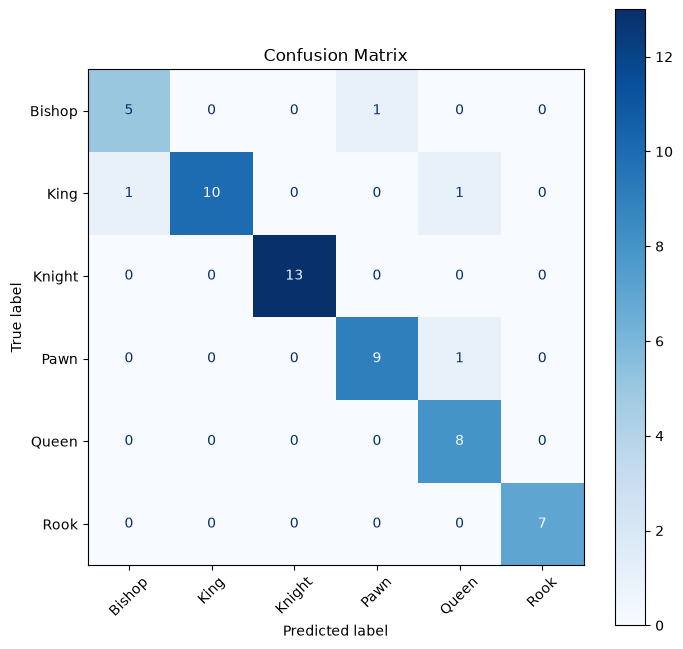

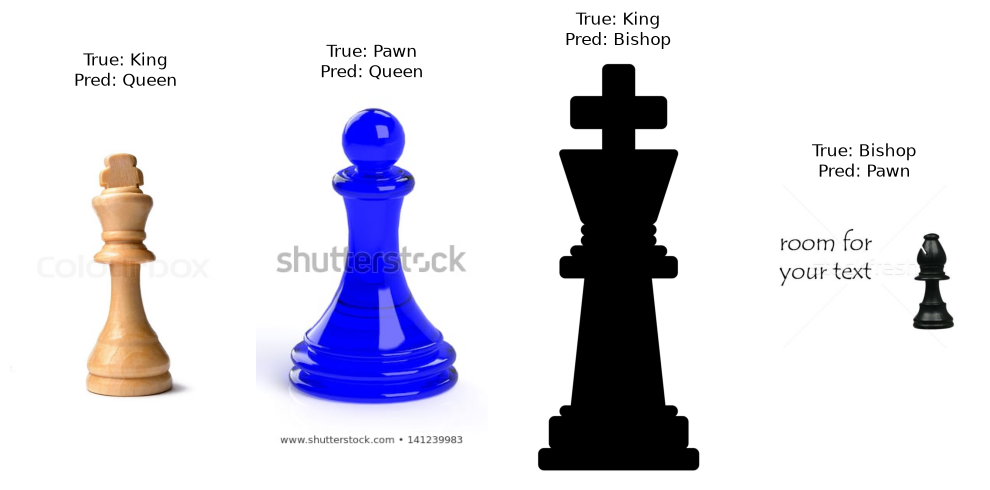

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [11]:
##### Evaluate on the held-out test set

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

predictions = trainer.predict(prepared_dataset["test"])
full_finetune_test_metrics = predictions.metrics
print(full_finetune_test_metrics)

predicted_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

incorrect_indices = np.where(true_labels != predicted_labels)[0]
incorrect_labels = predicted_labels[incorrect_indices]
true_labels_incorrect = true_labels[incorrect_indices]

label_feature = dataset["test"].features["label"]
incorrect_label_names = label_feature.int2str(incorrect_labels)
true_label_names_incorrect = label_feature.int2str(true_labels_incorrect)

print("Incorrectly classified sample indices:", incorrect_indices)
print("Predicted label names for incorrect samples:", incorrect_label_names)
print("True label names for incorrect samples:", true_label_names_incorrect)

incorrect_samples = dataset["test"].select(incorrect_indices)

#### Confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)
label_names = label_feature.names

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(
    values_format='d', cmap='Blues', ax=ax, xticks_rotation=45
)
plt.title('Confusion Matrix')
plt.show()

#### Visualize a few misclassified samples
num_plots = min(5, len(incorrect_samples))

plt.figure(figsize=(10, 5))
for i in range(num_plots):
    idx = incorrect_indices[i]
    sample = dataset["test"][int(idx)]
    image = sample['image']

    plt.subplot(1, num_plots, i + 1)
    plt.imshow(image)
    plt.title(f"True: {true_label_names_incorrect[i]}\nPred: {incorrect_label_names[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

trainer.save_model("../../data/models/dinov2-finetuned-chessman-final")

In [12]:
##### PEFT (LoRA) fine-tuning, for comparison against the full fine-tune above
##### Start from a fresh copy of the pretrained backbone (the `model` above has already been fully fine-tuned)

from peft import LoraConfig, get_peft_model

base_model = AutoModelForImageClassification.from_pretrained(checkpoint, num_labels=num_classes)

lora_config = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules=["query", "value"],  # attention projections in Dinov2's transformer blocks
    lora_dropout=0.1,
    modules_to_save=["classifier"],     # the new classification head is still trained in full
)

lora_model = get_peft_model(base_model, lora_config)
lora_model.print_trainable_parameters()

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

[transformers] Dinov2ForImageClassification LOAD REPORT from: facebook/dinov2-base
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 599,046 || all params: 87,188,748 || trainable%: 0.6871


In [13]:
##### Train the LoRA-adapted model
##### Same schedule/regularization as the full fine-tune, except the learning rate is raised
##### (LoRA only updates a small set of new low-rank adapter weights, so it tolerates and
##### benefits from a higher learning rate than full fine-tuning does).

lora_training_args = TrainingArguments(
    output_dir="../../data/models/dinov2-lora-finetuned-chessman",

    num_train_epochs=30,
    learning_rate=1e-3,
    warmup_steps=30,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    weight_decay=0.01,

    logging_strategy="epoch",
    eval_strategy="epoch",
    save_strategy="epoch",

    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    push_to_hub=False,
    dataloader_pin_memory=False,
    seed=42,

    report_to="trackio",
    project="dinov2-chessman-comparison",
    run_name="lora-finetune",
)

lora_early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=6,
    early_stopping_threshold=0.0,
)

lora_trainer = Trainer(
    model=lora_model,
    args=lora_training_args,
    train_dataset=prepared_dataset["train"],
    eval_dataset=prepared_dataset["validation"],
    compute_metrics=compute_metrics,
    callbacks=[lora_early_stopping_callback]
)
lora_finetune_result = lora_trainer.train()
lora_finetune_result

* Run finished. Uploading logs to Trackio (please wait...)
* Created new run: lora-finetune


Epoch,Training Loss,Validation Loss,Accuracy
1,1.381081,0.607716,0.763636
2,0.302656,0.394745,0.818182
3,0.102394,0.316037,0.854545
4,0.044023,0.204743,0.927273
5,0.027843,0.397896,0.927273
6,0.005829,0.446517,0.872727
7,0.016066,0.461646,0.890909
8,0.001452,0.725161,0.854545
9,0.014961,0.365270,0.872727
10,0.000083,0.335526,0.890909


* Run finished. Uploading logs to Trackio (please wait...)


TrainOutput(global_step=280, training_loss=0.18963882501453294, metrics={'train_runtime': 196.4062, 'train_samples_per_second': 67.513, 'train_steps_per_second': 4.277, 'total_flos': 3.480577052191949e+17, 'train_loss': 0.18963882501453294, 'epoch': 10.0})

* Resumed existing run: lora-finetune


{'test_loss': 0.13279786705970764, 'test_accuracy': 0.9642857142857143, 'test_runtime': 1.3618, 'test_samples_per_second': 41.122, 'test_steps_per_second': 2.937}
Incorrectly classified sample indices: [ 0 10]
Predicted label names for incorrect samples: ['Bishop', 'Queen']
True label names for incorrect samples: ['Rook', 'Pawn']


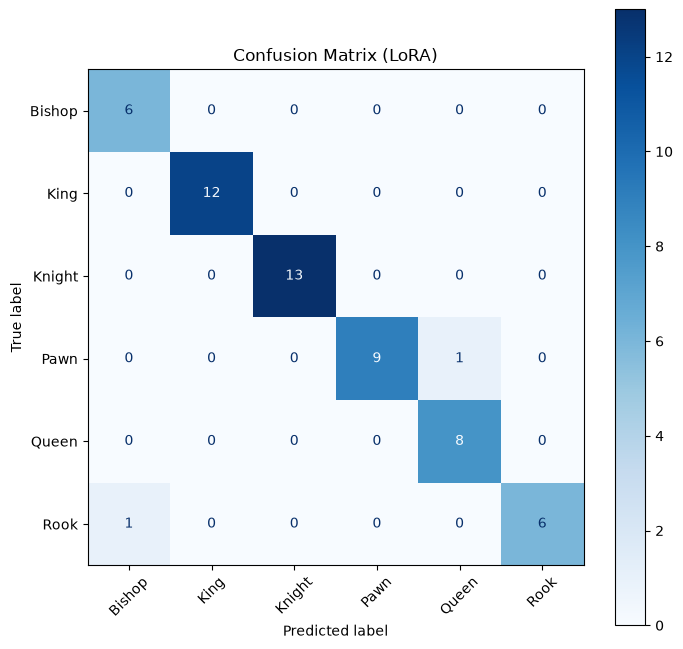

In [14]:
##### Evaluate the LoRA-adapted model on the held-out test set

lora_predictions = lora_trainer.predict(prepared_dataset["test"])
lora_test_metrics = lora_predictions.metrics
print(lora_test_metrics)

lora_predicted_labels = np.argmax(lora_predictions.predictions, axis=-1)
lora_true_labels = lora_predictions.label_ids

lora_incorrect_indices = np.where(lora_true_labels != lora_predicted_labels)[0]
print("Incorrectly classified sample indices:", lora_incorrect_indices)
print("Predicted label names for incorrect samples:",
      label_feature.int2str(lora_predicted_labels[lora_incorrect_indices]))
print("True label names for incorrect samples:",
      label_feature.int2str(lora_true_labels[lora_incorrect_indices]))

lora_cm = confusion_matrix(lora_true_labels, lora_predicted_labels)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(lora_cm, display_labels=label_names).plot(
    values_format='d', cmap='Blues', ax=ax, xticks_rotation=45
)
plt.title('Confusion Matrix (LoRA)')
plt.show()

lora_trainer.save_model("../../data/models/dinov2-lora-finetuned-chessman-final")

In [15]:
##### Full fine-tuning vs LoRA: side-by-side comparison

full_trainable, full_total = model.num_parameters(only_trainable=True), model.num_parameters()
lora_trainable, lora_total = lora_model.get_nb_trainable_parameters()

comparison = {
    "Full fine-tune": {
        "trainable params": full_trainable,
        "trainable %": round(100 * full_trainable / full_total, 4),
        "train_runtime (s)": round(full_finetune_result.metrics["train_runtime"], 1),
        "epochs trained": full_finetune_result.metrics["epoch"],
        "test_accuracy": full_finetune_test_metrics["test_accuracy"],
    },
    "LoRA": {
        "trainable params": lora_trainable,
        "trainable %": round(100 * lora_trainable / lora_total, 4),
        "train_runtime (s)": round(lora_finetune_result.metrics["train_runtime"], 1),
        "epochs trained": lora_finetune_result.metrics["epoch"],
        "test_accuracy": lora_test_metrics["test_accuracy"],
    },
}

import pandas as pd
pd.DataFrame(comparison)

,Full fine-tune,LoRA
trainable params,8.658970e+07,599046.000000
trainable %,1.000000e+02,0.687100
train_runtime (s),2.577000e+02,196.400000
epochs trained,9.000000e+00,10.000000
test_accuracy,9.285714e-01,0.964286
